In [11]:
import pandas as pd
import matplotlib.pyplot as plt

In [12]:
!pip install folium

In [13]:
import folium

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\cognifyz internship\Dataset .csv")
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [17]:
df = pd.read_csv(r"C:\cognifyz internship\Dataset .csv")

# Check required columns
df[['Latitude', 'Longitude', 'City', 'Country Code', 'Aggregate rating']].head()

,Latitude,Longitude,City,Country Code,Aggregate rating
0,14.565443,121.027535,Makati City,162,4.8
1,14.553708,121.014101,Makati City,162,4.5
2,14.581404,121.056831,Mandaluyong City,162,4.4
3,14.585318,121.056475,Mandaluyong City,162,4.9
4,14.584450,121.057508,Mandaluyong City,162,4.8


In [19]:
# Create base map (centered at mean location)
map_center = [df['Latitude'].mean(), df['Longitude'].mean()]

restaurant_map = folium.Map(location=map_center, zoom_start=5)

# Add points
for _, row in df.iterrows():
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=3,
        popup=f"Rating: {row['Aggregate rating']}",
        fill=True
    ).add_to(restaurant_map)

# Save map
restaurant_map.save("restaurant_map.html")

City
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Bhubaneshwar      21
Lucknow           21
Ahmedabad         21
Amritsar          21
Guwahati          21
Name: count, dtype: int64


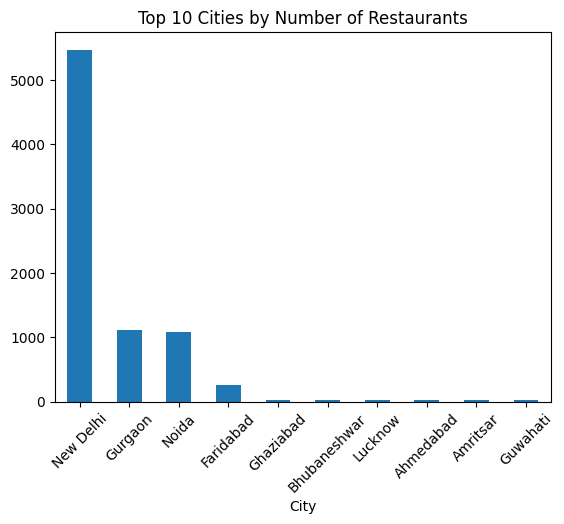

In [20]:
city_counts = df['City'].value_counts()

# Top 10 cities
top_cities = city_counts.head(10)
print(top_cities)

# Plot
top_cities.plot(kind='bar')
plt.title("Top 10 Cities by Number of Restaurants")
plt.xticks(rotation=45)
plt.show()

Country Code
1      8652
216     434
215      80
30       60
189      60
214      60
148      40
208      34
14       24
162      22
Name: count, dtype: int64


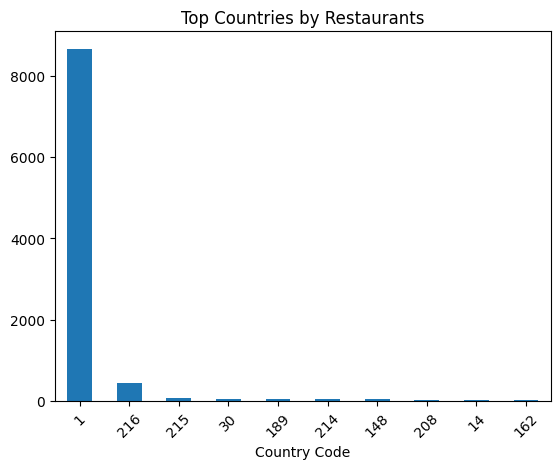

In [21]:
country_counts = df['Country Code'].value_counts()

print(country_counts.head(10))

country_counts.head(10).plot(kind='bar')
plt.title("Top Countries by Restaurants")
plt.xticks(rotation=45)
plt.show()

In [22]:
correlation = df[['Latitude', 'Longitude', 'Aggregate rating']].corr()
print(correlation)

                  Latitude  Longitude  Aggregate rating
Latitude          1.000000   0.043207          0.000516
Longitude         0.043207   1.000000         -0.116818
Aggregate rating  0.000516  -0.116818          1.000000


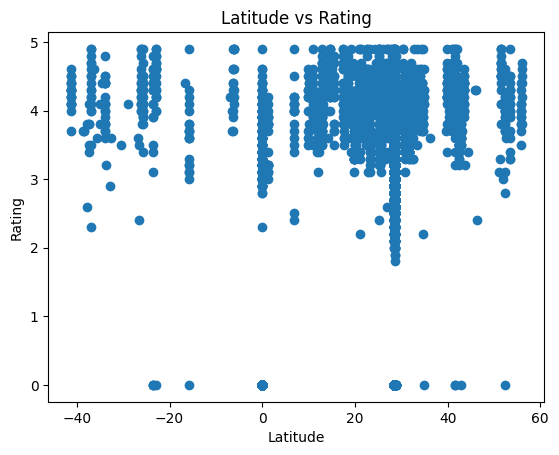

In [23]:
plt.scatter(df['Latitude'], df['Aggregate rating'])
plt.xlabel("Latitude")
plt.ylabel("Rating")
plt.title("Latitude vs Rating")
plt.show()

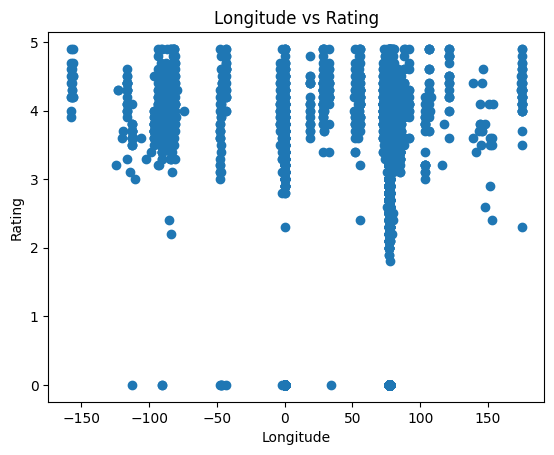

In [24]:
plt.scatter(df['Longitude'], df['Aggregate rating'])
plt.xlabel("Longitude")
plt.ylabel("Rating")
plt.title("Longitude vs Rating")
plt.show()

City
Inner City          4.900000
Quezon City         4.800000
Makati City         4.650000
Pasig City          4.633333
Mandaluyong City    4.625000
Beechworth          4.600000
London              4.535000
Taguig City         4.525000
Secunderabad        4.500000
Lincoln             4.500000
Name: Aggregate rating, dtype: float64


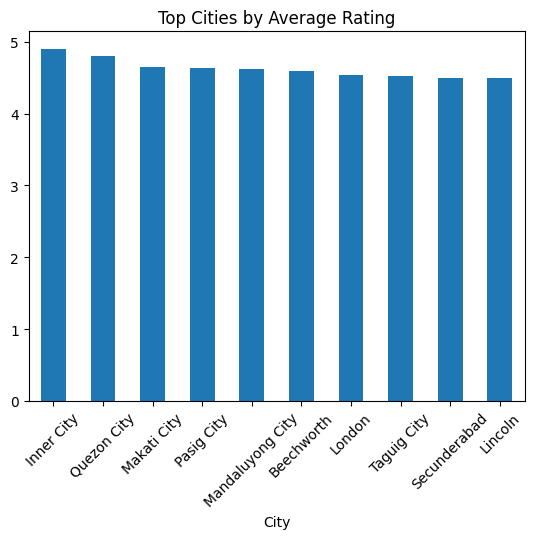

In [25]:
city_rating = df.groupby('City')['Aggregate rating'].mean().sort_values(ascending=False)

print(city_rating.head(10))

city_rating.head(10).plot(kind='bar')
plt.title("Top Cities by Average Rating")
plt.xticks(rotation=45)
plt.show()